In [ ]:
# ── Colab setup ────────────────────────────────────────────────────────────
# Runtime → Change runtime type → T4 GPU  (do this first!)

# Install dependencies (only needed the first run in Colab)
!pip install -q gym[classic_control] torch numpy pyyaml

# Mount your Drive to access your project files
from google.colab import drive
drive.mount('/content/drive')

# Point to your project root (adjust path as needed)
import sys, os
PROJECT_ROOT = "/content/drive/MyDrive/rl_course/applied_project"
sys.path.append(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# NumPy 2.0 compatibility patch (same as local)
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# Verify GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

## Imports

In [1]:
import os
print(os.getcwd())

c:\Users\coudu\OneDrive\Documents\Work\Master\Ma4\Reinforcement Learning\rl_course\applied_project


In [2]:
import gymnasium as gym
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import pickle as pkl
import yaml
import zipfile

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

# Custom modules
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.append(os.path.abspath('applied_project'))
from src import *
from src.csil import run_csil, evaluate_policy
%load_ext autoreload
%autoreload 2

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Global Variables & Config

In [ ]:
RANDOM_SEED = 42

# ------------------------------
# Expert Training Parameters
# ------------------------------
TRAIN_EXPERTS = False    # If false, use trained policies in ./policies/ saved with pickle
TRAIN_IQLEARN = False
TRAIN_CSIL = False
TRAIN_SOAR = False

DATASET_SIZES = [10, 100]

# Environment 1
ENV_1 = {
    'label' : "CartPole-v1",
    'nb_episodes' : 2000,
    'early_stop' : True,
    'hidden_size' : 32,
}

# Environment 2
ENV_2 = {
    'label' : "Pendulum-v1",
    'nb_episodes' : 2000,
    'early_stop' : True,
    'hidden_size' : 32,
}

# Environment 3
ENV_3 = {
    'label' : "MountainCar-v0",
    'nb_episodes' : 2000,
    'early_stop' : True,
    'hidden_size' : 32,
}

## Initialization

In [18]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [19]:
environments = [ENV_1, ENV_2, ENV_3]

for i in range(3):
    environments[i]['env'] = initialize_env(environments[i]['label'], RANDOM_SEED, print_spaces=True)

np.random.seed(RANDOM_SEED)

-------------------------
Environment: CartPole-v1
Action space: Discrete(2)
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
-------------------------
-------------------------
Environment: Pendulum-v1
Action space: Box(-2.0, 2.0, (1,), float32)
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
-------------------------
-------------------------
Environment: MountainCar-v0
Action space: Discrete(3)
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
-------------------------


## Run

### Expert Policy Generation

In [20]:
if TRAIN_EXPERTS:
    expert_policies = []

    for env, i in (environments, range(3)):
        print(f"Starting expert training for environment {i}: {env['label']}")
        policy = Policy(device, env['env'].observation_space.shape[0], env['env'].action_space.n, env['env'].hidden_size).to(device)
        optimizer = optim.Adam(policy.parameters(), lr=1e-2)
        scores_vanilla = reinforce(env, policy, optimizer, baseline_id=i, early_stop=env['early_stop'], n_episodes=env['nb_episodes'])
        expert_policies.append(policy)
else:
    expert_policies = {}
    for env in [ENV_1]: # environments:
        for dataset_size in DATASET_SIZES:
            path = f"./results/expert_datasets/{env['label']}/expert_K{dataset_size}_seed0.npz"
            policy = np.load(path)
            expert_policies[(env['label'], dataset_size)] = policy

for policy in expert_policies:
    print(policy)


('CartPole-v1', 10)
('CartPole-v1', 100)


### Extract Expert Datasets

### Train IL Policies

#### IQ-Learn

In [21]:
if TRAIN_IQLEARN:
    print("Training IQ-Learn agents...")

#### CSIL

In [ ]:
if TRAIN_CSIL:
    csil_agents = []
    csil_scores = []
    bc_policies = []

    with open("config/csil_params.yaml", "r") as f:
            csil_dict = yaml.safe_load(f)

    for env_dic in [ENV_1]: # (environments, range(3)):
        for dataset_size in DATASET_SIZES:
            expert_policy = expert_policies[(env_dic['label'], dataset_size)]
            csil_agent, episode_scores, bc_policy = run_csil(env_dic['env'],
                                                            expert_states=expert_policy['states'],
                                                            expert_actions=expert_policy['actions'],
                                                            csil_dict=csil_dict
                                                        )
            csil_agents.append(csil_agent)
            csil_scores.append(episode_scores)
            bc_policies.append(bc_policy)

    pkl.dump(csil_agents, open("./results/csil/csil_agents.pkl", "wb"))
    pkl.dump(csil_scores, open("./results/csil/csil_scores.pkl", "wb"))
    pkl.dump(bc_policies, open("./results/csil/bc_policies.pkl", "wb"))
else:
    print("Loading pre-trained CSIL agents...")
    csil_agents = pkl.load(open("./results/csil/csil_agents.pkl", "rb"))
    csil_scores = pkl.load(open("./results/csil/csil_scores.pkl", "rb"))
    bc_policies = pkl.load(open("./results/csil/bc_policies.pkl", "rb"))

Parameters loaded:
  BC: hidden_size=64, epochs=200, lr=0.0003, batch_size=256
  SAC: hidden_size=64, lr=0.0003, gamma=0.99, tau=0.005
Phase 1 — Behavioural Cloning
  [BC] Epoch   20/200 | NLL: 0.3339
  [BC] Epoch   40/200 | NLL: 0.3220
  [BC] Epoch   60/200 | NLL: 0.3106
  [BC] Epoch   80/200 | NLL: 0.3030
  [BC] Epoch  100/200 | NLL: 0.2917
  [BC] Epoch  120/200 | NLL: 0.2780
  [BC] Epoch  140/200 | NLL: 0.2532
  [BC] Epoch  160/200 | NLL: 0.2293
  [BC] Epoch  180/200 | NLL: 0.2026
  [BC] Epoch  200/200 | NLL: 0.1762
  BC training done. Final NLL: 0.1762

Phase 2 — CSIL Fine-tuning with SAC + Coherent Reward
  α_csil = 1.0
[CSIL] SAC actor warm-started from BC policy weights.
  Ep    50 | Score:    35.0 | Avg(100):    27.8 | Steps:    1391
  Ep   100 | Score:   500.0 | Avg(100):   211.2 | Steps:   21125
  Ep   150 | Score:    85.0 | Avg(100):   249.5 | Steps:   26337
  Ep   200 | Score:    17.0 | Avg(100):    90.7 | Steps:   30192
  Ep   250 | Score:    47.0 | Avg(100):    63.0 | Ste

#### SOAR Enhanced CSIL

2 2 2


## Results Plotting

#### Evaluation

In [ ]:
for env_dic in [ENV_1]: # (environments, range(3)):
    # Evaluate baselines (expert and random) for each environment
    env_name = env_dic['label']
    expert_model_path = "./results/policies/" + env_name + "/ppo_expert_seed_0.zip"
    random_score, random_std = evaluate_random_policy(env_name)
    expert_score, expert_std = evaluate_expert_policy(env_name, expert_model_path)

In [ ]:
csil_results_mean = []
csil_results_std = []

# Evaluate CSIL agents for each env and dataset size
i = -1
for agent in csil_agents:
    i += 1
    env_index = i // 3
    env_dic = environments[env_index]
    mean_reward, std_reward = evaluate_policy(env_dic['env'], agent=agent, csil_dict=csil_dict)
    csil_results_mean.append(mean_reward)
    csil_results_std.append(std_reward)
    

CartPole-v1 <src.csil.CSILAgent object at 0x0000015044829E10>
CartPole-v1 <src.csil.CSILAgent object at 0x000001503CE446D0>


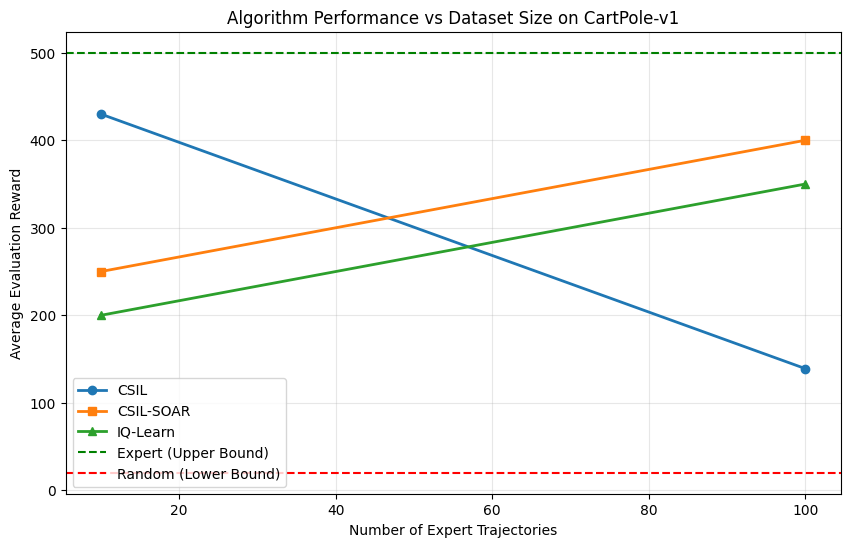

In [36]:
# Assume you have collected these dictionaries from your training loops
# Format: { dataset_size: mean_reward }
i = -1
for env_dic in [ENV_1]: # environments:
    i += 1
    csil_results = csil_results_mean[i*2:(i+1)*2]
    csil_soar_results = {10: 250, 100: 400}
    iq_learn_results = {10: 200, 100: 350}

    dataset_sizes = DATASET_SIZES
    env_name = env_dic['label']

    # 2. Plotting
    plt.figure(figsize=(10, 6))

    # Plot Algorithms
    plt.plot(dataset_sizes, csil_results, marker='o', label='CSIL', linewidth=2)
    plt.plot(dataset_sizes, list(csil_soar_results.values()), marker='s', label='CSIL-SOAR', linewidth=2)
    plt.plot(dataset_sizes, list(iq_learn_results.values()), marker='^', label='IQ-Learn', linewidth=2)

    # Plot Bounds
    plt.axhline(y=expert_score, color='g', linestyle='--', label='Expert (Upper Bound)')
    # plt.axhline(y=[expert_score-expert_std, expert_score+expert_std], color='r', linestyle='--')
    plt.axhline(y=random_score, color='r', linestyle='--', label='Random (Lower Bound)')
    # plt.axhline(y=[random_score-random_std, random_score+random_std], color='r', linestyle='--')

    plt.title(f"Algorithm Performance vs Dataset Size on {env_name}")
    plt.xlabel("Number of Expert Trajectories")
    plt.ylabel("Average Evaluation Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()